### Chat Bots with Google Colab

In [ ]:
!pip install langgraph langsmith

In [ ]:
!pip install langchain langchain_groq langchain_community

In [ ]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API_KEY")
langsmith=userdata.get("LANGCHAIN_API_KEY")

In [ ]:
import os
os.environ["LANGCHAIN_API_KEY"] = langsmith
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="LanggraphDemo"

In [ ]:
!pip install langchain-groq

In [ ]:
from langchain_groq import ChatGroq

In [ ]:
llm=ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7b21b1f65700>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7b21b1f66c60>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

In [ ]:
graph_builder=StateGraph(State)
graph_builder

In [ ]:
def chatbot(state:State):
  return {"messages":llm.invoke(state['messages'])}

In [ ]:
graph_builder.add_node('chatbot', chatbot)
graph_builder

# In Langgraph START node is always the starting edge and END node is always on the end edge

In [ ]:
# It add the Start node, which is then appended with 'chatbot' node which we added in previous section
graph_builder.add_edge(START, 'chatbot')
# It appends the End node after the 'chatbot' node
graph_builder.add_edge('chatbot', END)
# So now the flow is - START node -> chatbot node -> END node
# You can see the flow in following section output

In [ ]:
graph=graph_builder.compile()

## Now let's display the graph

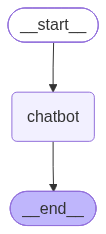

In [ ]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

## Now let's see some example of Chat

In [ ]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    # print(event.values())
    for value in event.values():
      # print(value['messages'])
      print("Assistant:",value["messages"].content)

User: hi
Assistant: How can I assist you today?
User: can you explain me generative ai
Assistant: Generative AI is a subfield of artificial intelligence that focuses on creating new, original content such as images, music, videos, text, and even entire worlds. This technology has advanced significantly in recent years, and its applications are diverse and exciting.

**Key Concepts:**

1. **Generative Models:** These are algorithms that can generate new content based on a given input, such as text, images, or audio. Generative models can learn patterns and relationships within the data and use this knowledge to create new, original content.
2. **Training Data:** Generative models require large amounts of training data to learn from. This data can be text, images, or audio, depending on the specific application.
3. **Loss Functions:** These are mathematical functions that measure the difference between the generated content and the target content. The goal is to minimize this difference 